In [23]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dython.nominal import associations

In [7]:
df = pd.read_csv("train.csv")
df.head()
df.info()
df.describe()
df.describe(include='object')

<class 'pandas.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   str    
 3   Sex                       5282 non-null   str    
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   str    
 6   HasChild                  5282 non-null   str    
 7   HasPhoneService           5282 non-null   str    
 8   HasMultiplePhoneNumbers   5282 non-null   str    
 9   HasInternetService        5282 non-null   str    
 10  HasOnlineSecurityService  5282 non-null   str    
 11  HasOnlineBackup           5282 non-null   str    
 12  HasDeviceProtection       5282 non-null   str    
 13  HasTechSupportAccess      5282 non-null   str    
 14  HasOnlineTV        

/tmp/ipykernel_94487/2209094577.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,TotalSpent,Sex,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod
count,5282,5282,5282,5282,5282,5282,5282,5282,5282,5282,5282,5282,5282,5282,5282,5282
unique,4978,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,20.2,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
freq,9,2655,2705,3676,4761,2511,2341,2612,2332,2317,2604,2099,2081,2920,3148,1786


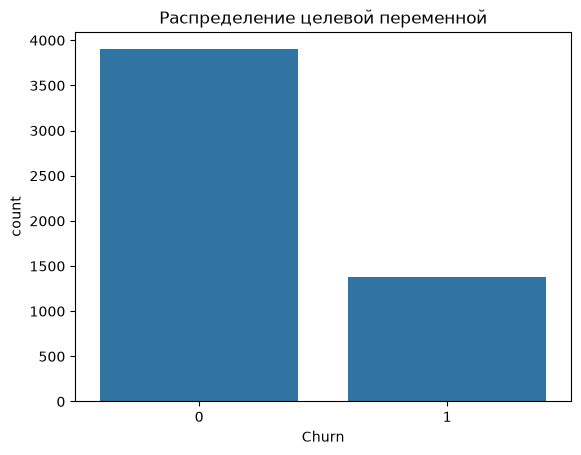

Churn
0    73.797804
1    26.202196
Name: proportion, dtype: float64


In [14]:
sns.countplot(x='Churn', data=df)
plt.title('Распределение целевой переменной')
plt.show()
print(df['Churn'].value_counts(normalize=True) * 100)

Распределение числовых признаков

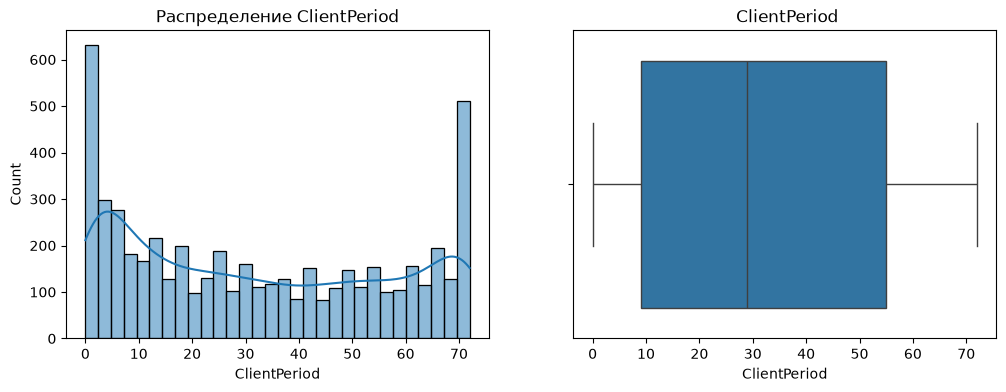

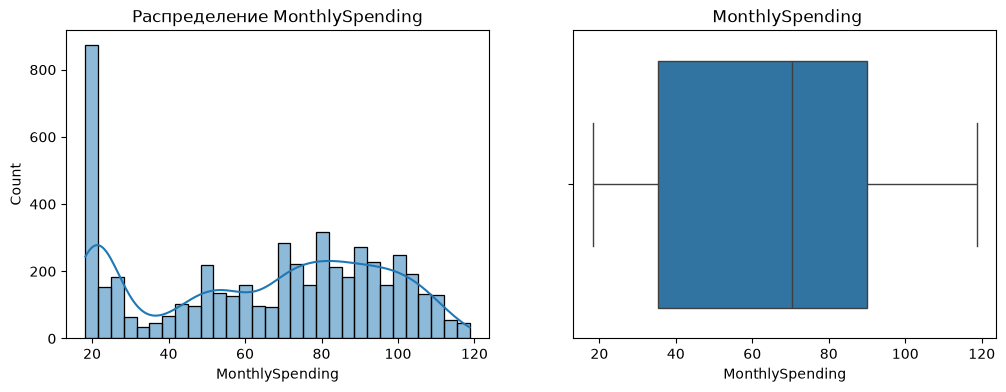

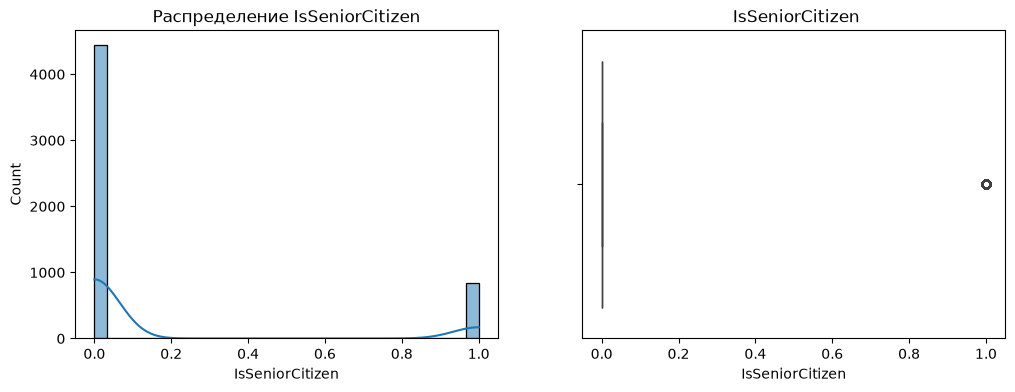

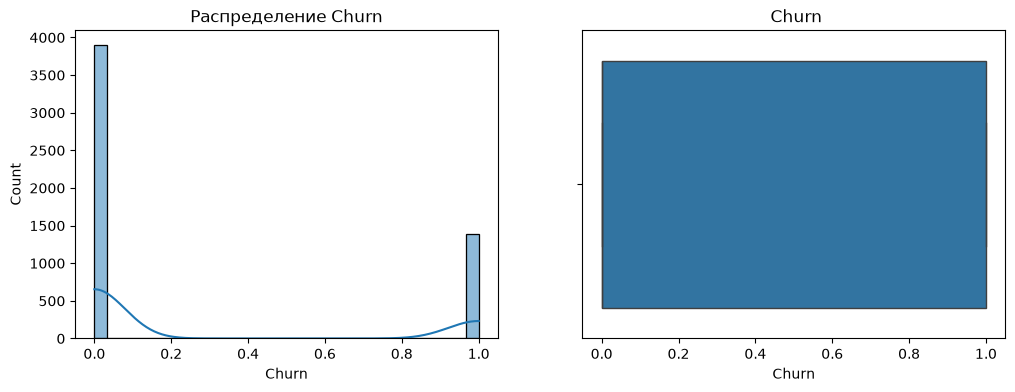

In [16]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], bins=30, kde=True, ax=ax[0])
    ax[0].set_title(f'Распределение {col}')
    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f' {col}')
    plt.show()

Частотный анализ категориальных признаков

Частотная таблица для TotalSpent:
TotalSpent
20.2       9
           9
19.75      8
19.65      6
20.05      6
          ..
82.15      1
2188.45    1
55.05      1
2215.25    1
1375.6     1
Name: count, Length: 4978, dtype: int64
---


/tmp/ipykernel_94487/3718978031.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns


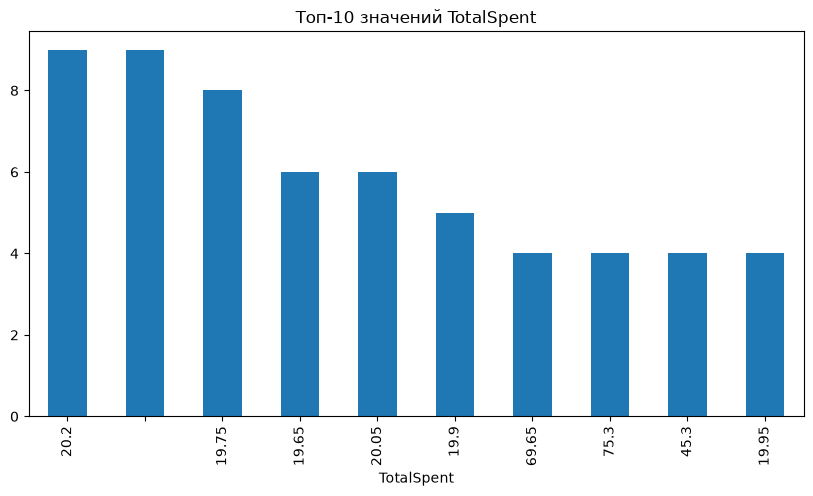

Частотная таблица для Sex:
Sex
Male      2655
Female    2627
Name: count, dtype: int64
---


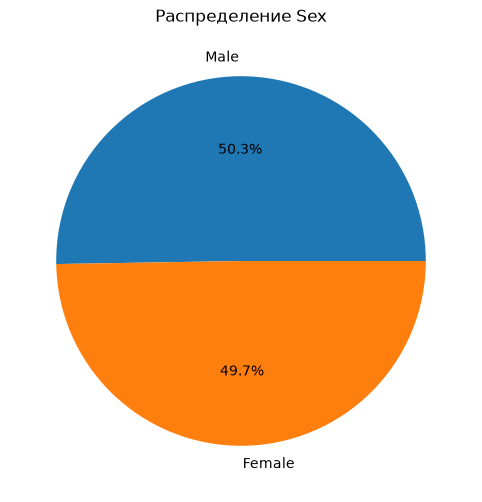

Частотная таблица для HasPartner:
HasPartner
No     2705
Yes    2577
Name: count, dtype: int64
---


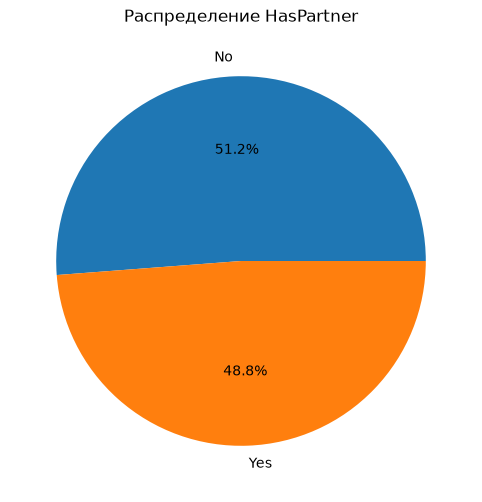

Частотная таблица для HasChild:
HasChild
No     3676
Yes    1606
Name: count, dtype: int64
---


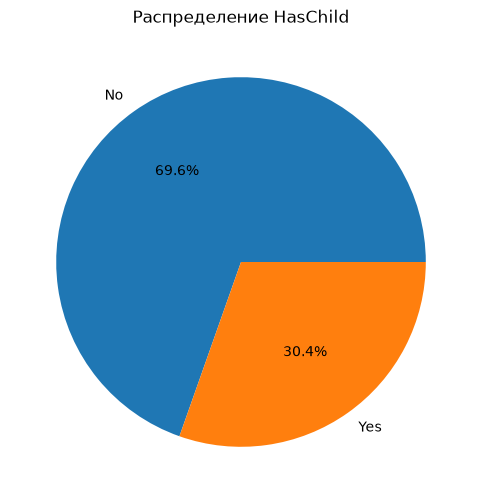

Частотная таблица для HasPhoneService:
HasPhoneService
Yes    4761
No      521
Name: count, dtype: int64
---


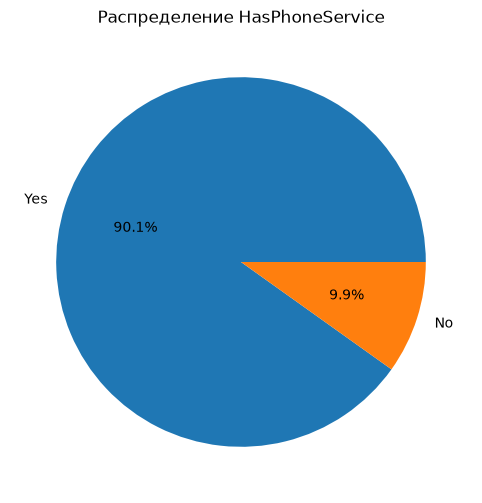

Частотная таблица для HasMultiplePhoneNumbers:
HasMultiplePhoneNumbers
No                  2511
Yes                 2250
No phone service     521
Name: count, dtype: int64
---


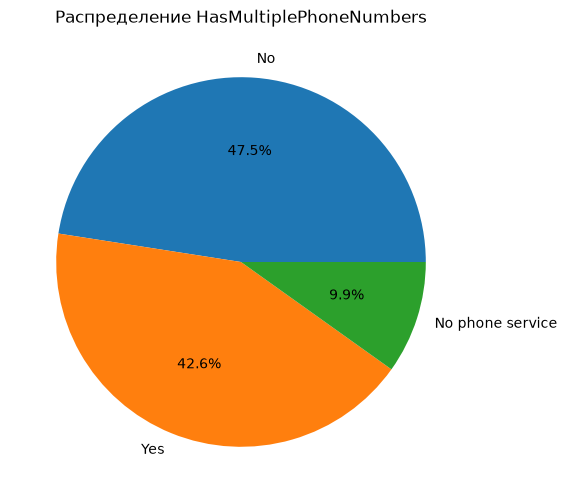

Частотная таблица для HasInternetService:
HasInternetService
Fiber optic    2341
DSL            1800
No             1141
Name: count, dtype: int64
---


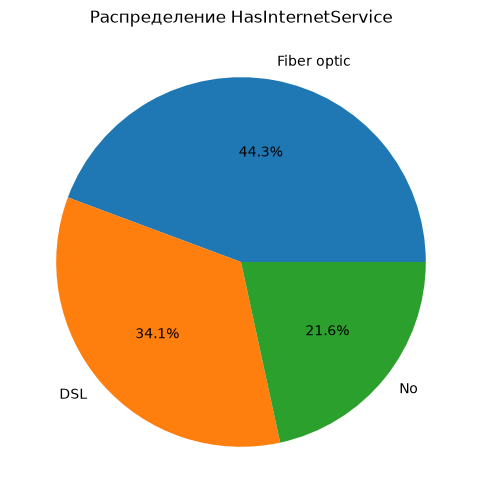

Частотная таблица для HasOnlineSecurityService:
HasOnlineSecurityService
No                     2612
Yes                    1529
No internet service    1141
Name: count, dtype: int64
---


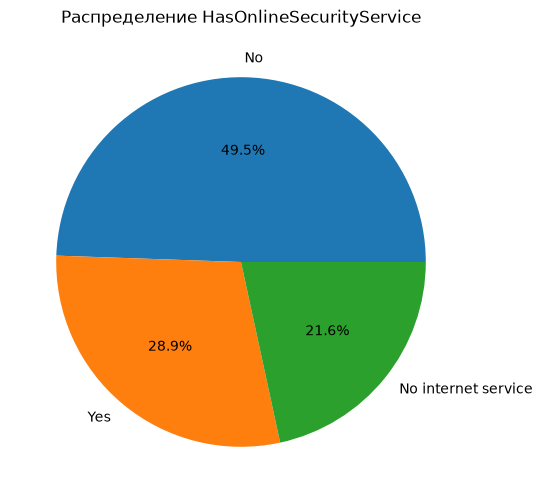

Частотная таблица для HasOnlineBackup:
HasOnlineBackup
No                     2332
Yes                    1809
No internet service    1141
Name: count, dtype: int64
---


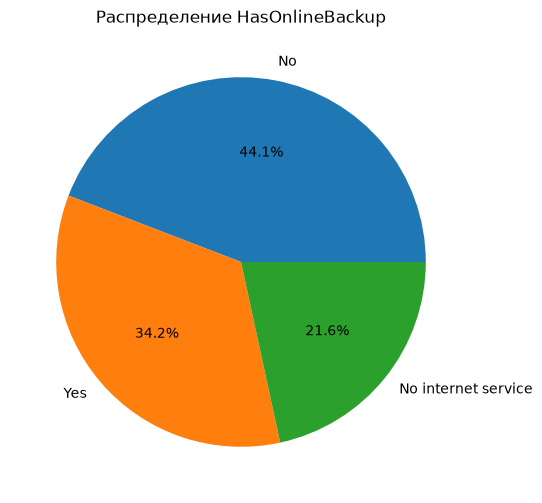

Частотная таблица для HasDeviceProtection:
HasDeviceProtection
No                     2317
Yes                    1824
No internet service    1141
Name: count, dtype: int64
---


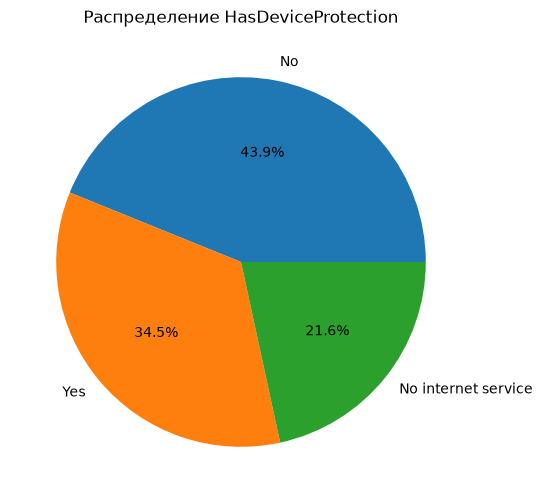

Частотная таблица для HasTechSupportAccess:
HasTechSupportAccess
No                     2604
Yes                    1537
No internet service    1141
Name: count, dtype: int64
---


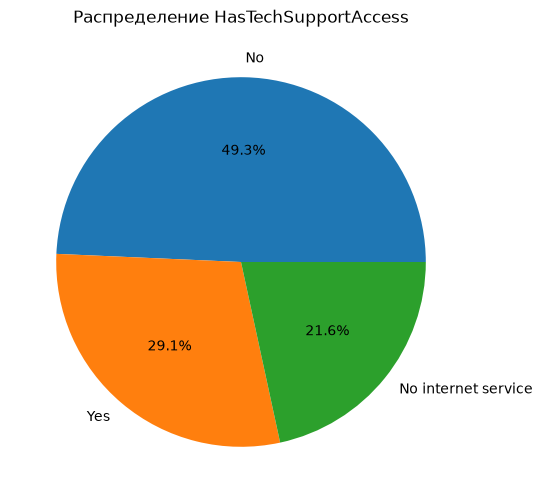

Частотная таблица для HasOnlineTV:
HasOnlineTV
No                     2099
Yes                    2042
No internet service    1141
Name: count, dtype: int64
---


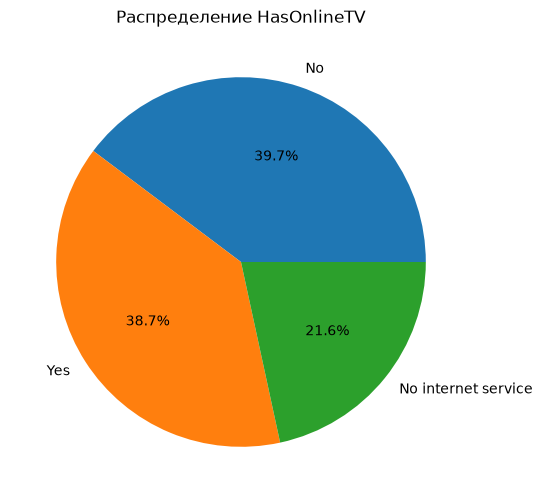

Частотная таблица для HasMovieSubscription:
HasMovieSubscription
No                     2081
Yes                    2060
No internet service    1141
Name: count, dtype: int64
---


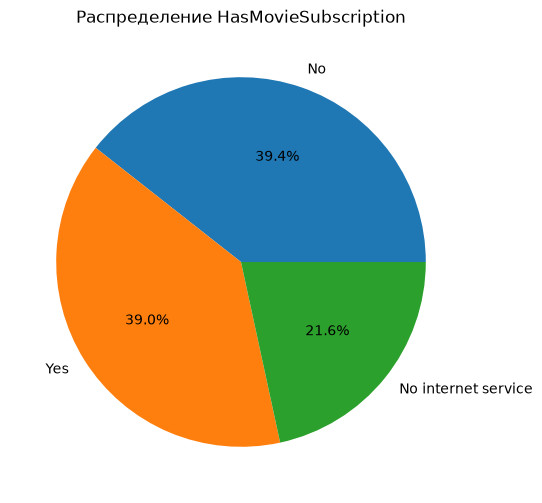

Частотная таблица для HasContractPhone:
HasContractPhone
Month-to-month    2920
Two year          1280
One year          1082
Name: count, dtype: int64
---


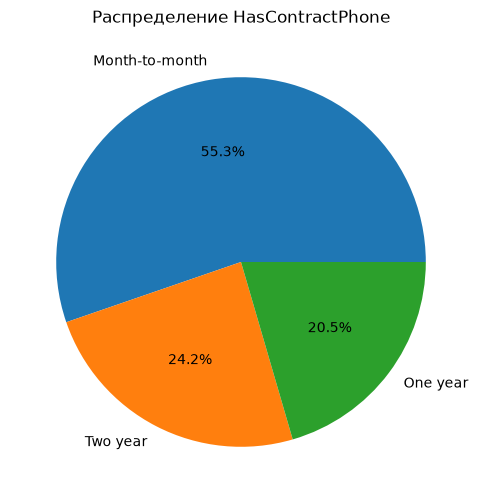

Частотная таблица для IsBillingPaperless:
IsBillingPaperless
Yes    3148
No     2134
Name: count, dtype: int64
---


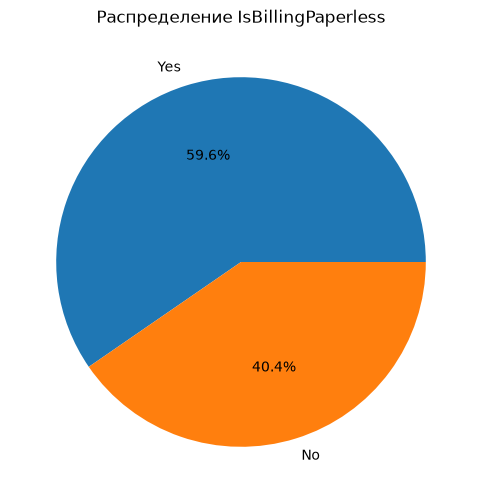

Частотная таблица для PaymentMethod:
PaymentMethod
Electronic check             1786
Mailed check                 1194
Bank transfer (automatic)    1159
Credit card (automatic)      1143
Name: count, dtype: int64
---


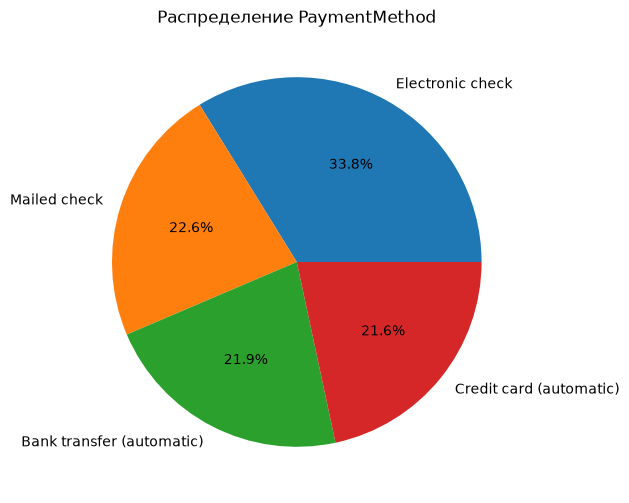

In [17]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
cat_cols = [c for c in cat_cols if c != 'Churn']

for col in cat_cols:
    print(f'Частотная таблица для {col}:')
    print(df[col].value_counts())
    print('---')
    if df[col].nunique() <= 10:
        df[col].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6,6))
        plt.title(f'Распределение {col}')
        plt.ylabel('')
        plt.show()
    else:
        df[col].value_counts().head(10).plot(kind='bar', figsize=(10,5))
        plt.title(f'Топ-10 значений {col}')
        plt.show()

Пропуски

In [ ]:
print(df.isnull().sum())

ClientPeriod                0
MonthlySpending             0
TotalSpent                  0
Sex                         0
IsSeniorCitizen             0
HasPartner                  0
HasChild                    0
HasPhoneService             0
HasMultiplePhoneNumbers     0
HasInternetService          0
HasOnlineSecurityService    0
HasOnlineBackup             0
HasDeviceProtection         0
HasTechSupportAccess        0
HasOnlineTV                 0
HasMovieSubscription        0
HasContractPhone            0
IsBillingPaperless          0
PaymentMethod               0
Churn                       0
dtype: int64


Корреляции

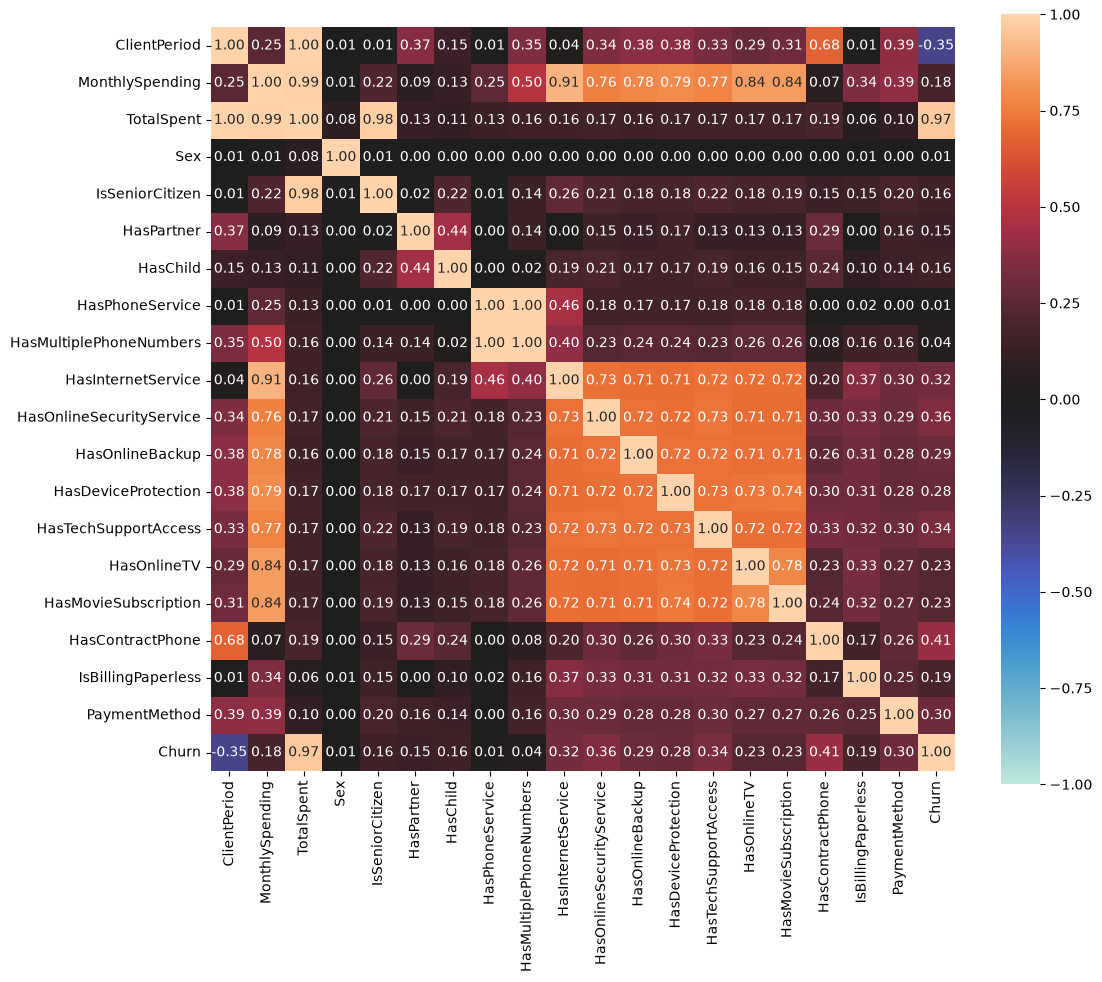

{'corr':                           ClientPeriod  MonthlySpending  TotalSpent       Sex  \
 ClientPeriod                  1.000000         0.249414    0.997638  0.006370   
 MonthlySpending               0.249414         1.000000    0.988603  0.011778   
 TotalSpent                    0.997638         0.988603    1.000000  0.081300   
 Sex                           0.006370         0.011778    0.081300  1.000000   
 IsSeniorCitizen               0.011561         0.215456    0.979419  0.013207   
 HasPartner                    0.370314         0.087652    0.132601  0.000000   
 HasChild                      0.146120         0.125682    0.105414  0.003479   
 HasPhoneService               0.013291         0.251283    0.133709  0.000000   
 HasMultiplePhoneNumbers       0.345528         0.499393    0.158192  0.000000   
 HasInternetService            0.038685         0.905155    0.159604  0.000000   
 HasOnlineSecurityService      0.343969         0.762974    0.166139  0.000000   
 HasOnli

In [ ]:
# матрица признаков
associations(df, nominal_columns='auto', figsize=(12, 10))

Категориальные переменные


In [ ]:
# Заменим TotalSpent на числовой тип данных перед one-hot кодированием
df['TotalSpent'] = df['TotalSpent'].str.strip().str.replace(',', '.')
df['TotalSpent'] = pd.to_numeric(df['TotalSpent'])

#Заполним пропуски позже, после разделения на train и test, чтобы избежать утечки данных.

cat_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

#print(df_encoded.shape)
#print(df_encoded.head())

/tmp/ipykernel_94487/2506444462.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


Разбиение данных на обучающую и тестовую выборки

In [ ]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
# Заполняем пропуски в TotalSpent медианой из обучающей выборки
median_total_spent = X_train['TotalSpent'].median()
X_train['TotalSpent'] = X_train['TotalSpent'].fillna(median_total_spent)
X_test['TotalSpent'] = X_test['TotalSpent'].fillna(median_total_spent)

Дерево решений не требует масштабирования, поскольку её пороги, не зависят от масштаба.

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

Стандртизация признаков

In [48]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Оценка моделей:

In [64]:
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
import matplotlib.pyplot as plt

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, use_scaled=False):
    X_tr = X_train_scaled if use_scaled else X_train
    X_te = X_test_scaled if use_scaled else X_test
    
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    
    print(f"\n{model_name}")
    print(classification_report(y_test, y_pred, digits=3))
    auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC: {auc:.3f}")
    
    # ROC-кривая
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} - ROC Curve')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

Логистическая регрессия


Logistic Regression
              precision    recall  f1-score   support

           0      0.911     0.735     0.813       780
           1      0.516     0.798     0.627       277

    accuracy                          0.751      1057
   macro avg      0.714     0.766     0.720      1057
weighted avg      0.808     0.751     0.764      1057

ROC-AUC: 0.854


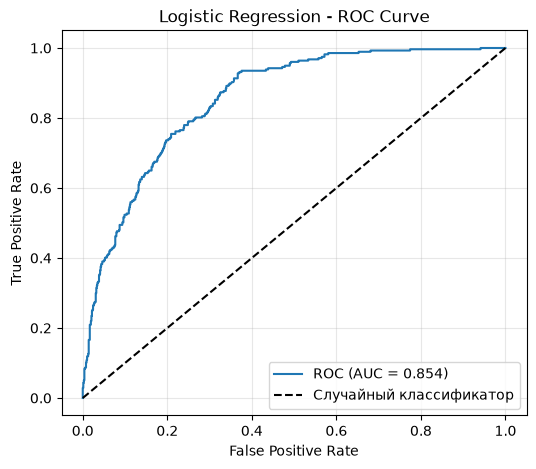

In [65]:
lr = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
evaluate_model(lr, X_train, X_test, y_train, y_test, 'Logistic Regression', use_scaled=True)

SVM

/home/kagor/work_model/trainings/task1/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



SVM (RBF)
              precision    recall  f1-score   support

           0      0.899     0.755     0.821       780
           1      0.525     0.762     0.622       277

    accuracy                          0.757      1057
   macro avg      0.712     0.758     0.721      1057
weighted avg      0.801     0.757     0.769      1057

ROC-AUC: 0.832


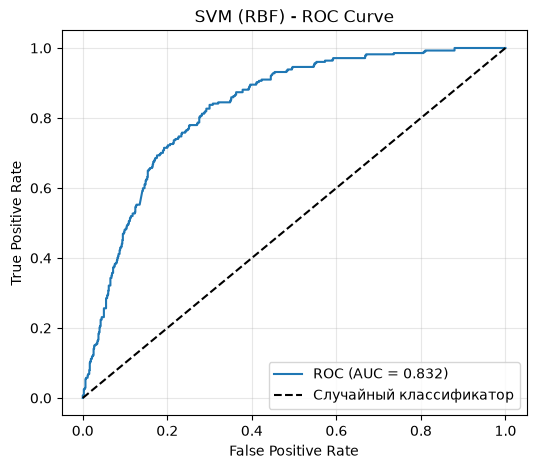

In [67]:
svm = SVC(random_state=42, class_weight='balanced', kernel='rbf', gamma='scale', probability=True)
evaluate_model(svm, X_train, X_test, y_train, y_test, 'SVM (RBF)', use_scaled=True)

knn


kNN (k=5)
              precision    recall  f1-score   support

           0      0.834     0.856     0.845       780
           1      0.562     0.520     0.540       277

    accuracy                          0.768      1057
   macro avg      0.698     0.688     0.693      1057
weighted avg      0.763     0.768     0.765      1057

ROC-AUC: 0.779


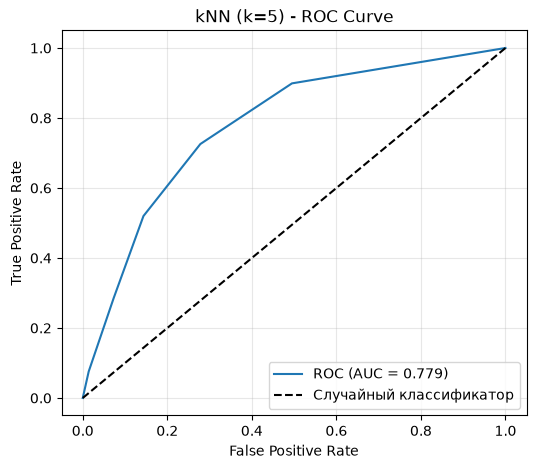

In [68]:
knn = KNeighborsClassifier(n_neighbors=5)
evaluate_model(knn, X_train, X_test, y_train, y_test, 'kNN (k=5)', use_scaled=True)

Дерево решений


===== Decision Tree =====
Confusion matrix:
 [[581 199]
 [ 68 209]]

Classification report:
              precision    recall  f1-score   support

           0      0.895     0.745     0.813       780
           1      0.512     0.755     0.610       277

    accuracy                          0.747      1057
   macro avg      0.704     0.750     0.712      1057
weighted avg      0.795     0.747     0.760      1057

ROC-AUC: 0.780


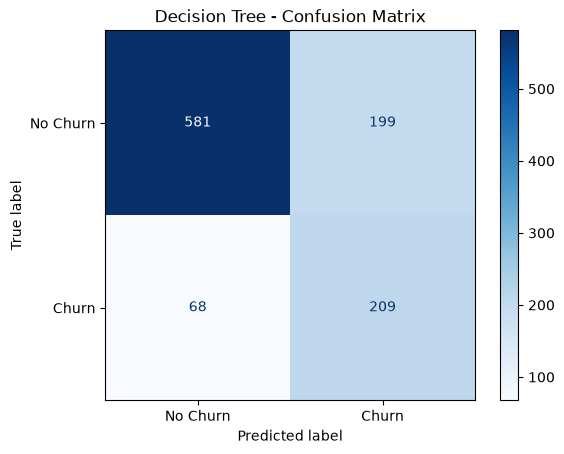

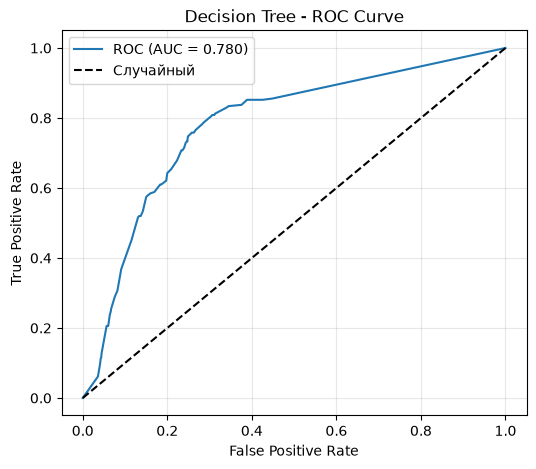

(DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42),
 array([0, 0, 0, ..., 1, 1, 1], shape=(1057,)))

In [60]:
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10)
evaluate_model(dt, X_train, X_test, y_train, y_test, 'Decision Tree', use_scaled=False)

Сравнение моделей по  ROC-AUC

In [73]:
from sklearn.metrics import roc_auc_score
import pandas as pd

models = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
    'SVM (RBF)': SVC(random_state=42, class_weight='balanced', kernel='rbf', gamma='scale'),
    'kNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10)
}

auc_list = []
for name, model in models.items():
    use_scaled = name != 'Decision Tree'
    X_tr = X_train_scaled if use_scaled else X_train
    X_te = X_test_scaled if use_scaled else X_test
    
    model.fit(X_tr, y_train)
    y_score = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_te)
    auc_list.append({'Model': name, 'ROC-AUC': roc_auc_score(y_test, y_score)})

comparison_df = pd.DataFrame(auc_list).sort_values('ROC-AUC', ascending=False)
print(comparison_df.round(3))

                 Model  ROC-AUC
0  Logistic Regression    0.854
1            SVM (RBF)    0.832
3        Decision Tree    0.780
2            kNN (k=5)    0.779


# Результат на Kaggle

![](image.png)